In [1]:
import pandas as pd
from pathlib import Path

In [2]:
RAW_DATA_DIR = Path("../data/raw")

TRAIN_PATH = RAW_DATA_DIR / "train_FD004.txt"
TEST_PATH = RAW_DATA_DIR / "test_FD004.txt"
TEST_RUL_PATH = RAW_DATA_DIR / "RUL_FD004.txt"

In [3]:
column_names = (
    ["engine_id", "cycle"]
    + ["setting_1", "setting_2", "setting_3"]
    + [f"sensor_{i}" for i in range(1, 22)]
)

In [4]:
train_fd004 = pd.read_csv(
    TRAIN_PATH,
    sep=r"\s+",
    header=None,
    names=column_names,
)

test_fd004 = pd.read_csv(
    TEST_PATH,
    sep=r"\s+",
    header=None,
    names=column_names,
)

rul_fd004 = pd.read_csv(
    TEST_RUL_PATH,
    sep=r"\s+",
    header=None,
    names=["rul"],
)



In [6]:


print("FD004 train shape:", train_fd004.shape)
print("FD004 test shape:", test_fd004.shape)
print("FD004 RUL shape:", rul_fd004.shape)

print()
print(
    "Train engines:",
    train_fd004["engine_id"].nunique()
)

print(
    "Test engines:",
    test_fd004["engine_id"].nunique()
)


FD004 train shape: (61249, 26)
FD004 test shape: (41214, 26)
FD004 RUL shape: (248, 1)

Train engines: 249
Test engines: 248


In [7]:
train_fd004.head()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,42.0049,0.8400,100.0,445.00,549.68,1343.43,1112.93,3.91,...,129.78,2387.99,8074.83,9.3335,0.02,330,2212,100.00,10.62,6.3670
1,1,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,9.35,...,312.59,2387.73,8046.13,9.1913,0.02,361,2324,100.00,24.37,14.6552
2,1,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,3.91,...,129.62,2387.97,8066.62,9.4007,0.02,329,2212,100.00,10.48,6.4213
3,1,4,42.0000,0.8400,100.0,445.00,548.70,1341.24,1118.03,3.91,...,129.80,2388.02,8076.05,9.3369,0.02,328,2212,100.00,10.54,6.4176
4,1,5,25.0063,0.6207,60.0,462.54,536.10,1255.23,1033.59,7.05,...,164.11,2028.08,7865.80,10.8366,0.02,305,1915,84.93,14.03,8.6754


In [8]:
train_fd004.nunique()

engine_id      249
cycle          543
setting_1      536
setting_2      105
setting_3        2
sensor_1         6
sensor_2      1704
sensor_3     13558
sensor_4     17353
sensor_5         6
sensor_6        46
sensor_7      5926
sensor_8      1038
sensor_9     25297
sensor_10       21
sensor_11      737
sensor_12     5627
sensor_13      483
sensor_14    15938
sensor_15    11915
sensor_16        2
sensor_17       54
sensor_18        6
sensor_19        2
sensor_20      652
sensor_21    21574
dtype: int64

In [9]:
train_fd004[
    ["setting_1", "setting_2", "setting_3"]
].describe()

,setting_1,setting_2,setting_3
count,61249.000000,61249.000000,61249.000000
mean,23.999823,0.571347,94.031576
std,14.780722,0.310703,14.251954
min,0.000000,0.000000,60.000000
25%,10.004600,0.250700,100.000000
50%,25.001400,0.700000,100.000000
75%,41.998100,0.840000,100.000000
max,42.008000,0.842000,100.000000


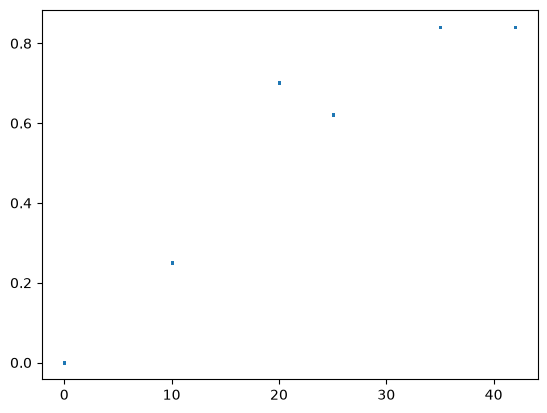

In [11]:
import matplotlib.pyplot as plt
plt.scatter(train_fd004['setting_1'], train_fd004['setting_2'], s=.2)

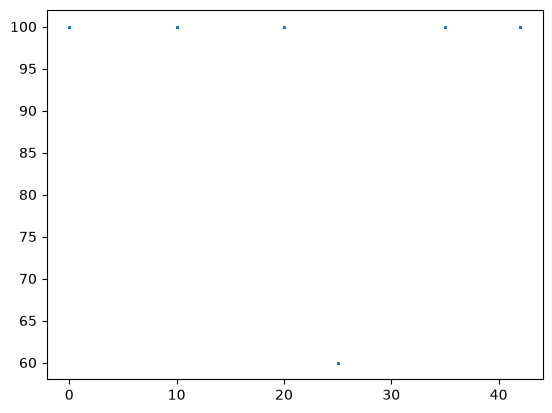

In [12]:
plt.scatter(train_fd004['setting_1'], train_fd004['setting_3'], s=.2)


In [13]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

settings = train_fd004[
    ["setting_1", "setting_2", "setting_3"]
].copy()

settings_scaler = StandardScaler()

settings_scaled = settings_scaler.fit_transform(
    settings
)

kmeans = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=20,
)

train_fd004["operating_condition"] = (
    kmeans.fit_predict(settings_scaled)
)

print(
    train_fd004["operating_condition"]
    .value_counts()
    .sort_index()
)

print()
print(
    train_fd004.groupby("operating_condition")[
        ["setting_1", "setting_2", "setting_3"]
    ].mean()
)

operating_condition
0    15395
1     9224
2     9139
3     9091
4     9238
5     9162
Name: count, dtype: int64

                     setting_1  setting_2  setting_3
operating_condition                                 
0                    42.002987   0.840495      100.0
1                    10.002990   0.250503      100.0
2                    25.003053   0.620504       60.0
3                    20.002974   0.700505      100.0
4                     0.001508   0.000495      100.0
5                    35.003029   0.840506      100.0


In [14]:
train_fd004

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,operating_condition
0,1,1,42.0049,0.8400,100.0,445.00,549.68,1343.43,1112.93,3.91,...,2387.99,8074.83,9.3335,0.02,330,2212,100.00,10.62,6.3670,0
1,1,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,9.35,...,2387.73,8046.13,9.1913,0.02,361,2324,100.00,24.37,14.6552,3
2,1,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,3.91,...,2387.97,8066.62,9.4007,0.02,329,2212,100.00,10.48,6.4213,0
3,1,4,42.0000,0.8400,100.0,445.00,548.70,1341.24,1118.03,3.91,...,2388.02,8076.05,9.3369,0.02,328,2212,100.00,10.54,6.4176,0
4,1,5,25.0063,0.6207,60.0,462.54,536.10,1255.23,1033.59,7.05,...,2028.08,7865.80,10.8366,0.02,305,1915,84.93,14.03,8.6754,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61244,249,251,9.9998,0.2500,100.0,489.05,605.33,1516.36,1315.28,10.52,...,2388.73,8185.69,8.4541,0.03,372,2319,100.00,29.11,17.5234,1
61245,249,252,0.0028,0.0015,100.0,518.67,643.42,1598.92,1426.77,14.62,...,2388.46,8185.47,8.2221,0.03,396,2388,100.00,39.38,23.7151,4
61246,249,253,0.0029,0.0000,100.0,518.67,643.68,1607.72,1430.56,14.62,...,2388.48,8193.94,8.2525,0.03,395,2388,100.00,39.78,23.8270,4
61247,249,254,35.0046,0.8400,100.0,449.44,555.77,1381.29,1148.18,5.48,...,2388.83,8125.64,9.0515,0.02,337,2223,100.00,15.26,9.0774,5


In [15]:
# We need to see sensor readings in these different operating conditions to 
# determine wether to scale globally or by operation_condition 

sensor_columns = [
    col
    for col in train_fd004.columns
    if col.startswith("sensor_")
]

condition_sensor_means = (
    train_fd004
    .groupby("operating_condition")[sensor_columns]
    .mean()
)

condition_sensor_means

,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
operating_condition,,,,,,,,,,,,,,,,,,,,,
0,445.00,549.477912,1352.562715,1124.490963,3.91,5.708030,138.928309,2212.005179,8327.564196,1.022520,...,130.824420,2388.089554,8090.707893,9.331878,0.020000,330.543813,2212.0,100.00,10.622848,6.372698
1,489.05,604.700575,1500.003491,1307.423831,10.52,15.482330,395.403328,2318.940497,8785.888140,1.260671,...,372.446648,2388.143264,8136.946143,8.621487,0.029996,369.188855,2319.0,100.00,28.636645,17.181134
2,462.54,536.738590,1260.672766,1046.772438,7.05,9.018245,175.764793,1915.411832,8014.089201,0.939716,...,164.877458,2028.310378,7877.958259,10.864516,0.020000,306.824926,1915.0,84.93,14.310108,8.587196
3,491.19,607.326724,1483.501860,1249.568890,9.35,13.639413,335.213732,2324.000843,8729.255494,1.078040,...,315.532601,2388.132323,8066.973056,9.190516,0.021609,364.825872,2324.0,100.00,24.533805,14.721140
4,518.67,642.496738,1588.519059,1405.249438,14.62,21.599282,555.114113,2388.084244,9063.492293,1.301242,...,523.031886,2388.084030,8143.464681,8.400411,0.030000,392.673306,2388.0,100.00,38.976661,23.388880
5,449.44,555.564542,1364.709756,1128.238337,5.48,7.990692,194.903643,2223.040970,8355.912172,1.023427,...,183.443833,2388.138346,8073.665918,9.288397,0.020000,333.727680,2223.0,100.00,14.882462,8.929792


In [ ]:
# checking standard deviation operating_condition wise

condition_sensor_stds = (
    train_fd004
    .groupby("operating_condition")[sensor_columns]
    .std()
)

condition_sensor_stds

,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
operating_condition,,,,,,,,,,,,,,,,,,,,,
0,0.0,0.464344,6.596366,9.019432,0.0,0.010704,1.035859,0.238848,18.530291,0.007002,...,0.955773,0.257921,16.795777,0.072170,0.000000,1.661203,0.0,0.0,0.118642,0.071299
1,0.0,0.517158,6.537669,9.392014,0.0,0.014746,2.380231,0.181144,18.893910,0.003137,...,2.239914,0.185848,15.984095,0.061943,0.000208,1.649454,0.0,0.0,0.192174,0.115425
2,0.0,0.385915,5.818127,7.476698,0.0,0.012161,1.040066,0.210621,13.292917,0.001814,...,0.958452,0.223318,11.747044,0.072857,0.000000,1.434721,0.0,0.0,0.128149,0.076447
3,0.0,0.508334,6.635482,8.893205,0.0,0.023126,2.121665,0.205268,17.821361,0.005717,...,1.994044,0.210951,15.176505,0.064949,0.003675,1.679991,0.0,0.0,0.174093,0.103932
4,0.0,0.514416,6.707031,9.731900,0.0,0.014899,3.468158,0.148508,19.271059,0.003505,...,3.279716,0.148678,16.081946,0.061042,0.000000,1.725006,0.0,0.0,0.253845,0.152258
5,0.0,0.485350,6.446601,8.651547,0.0,0.013209,1.369132,0.255978,17.794535,0.006748,...,1.276205,0.275062,15.927858,0.069497,0.000000,1.625363,0.0,0.0,0.134642,0.080526


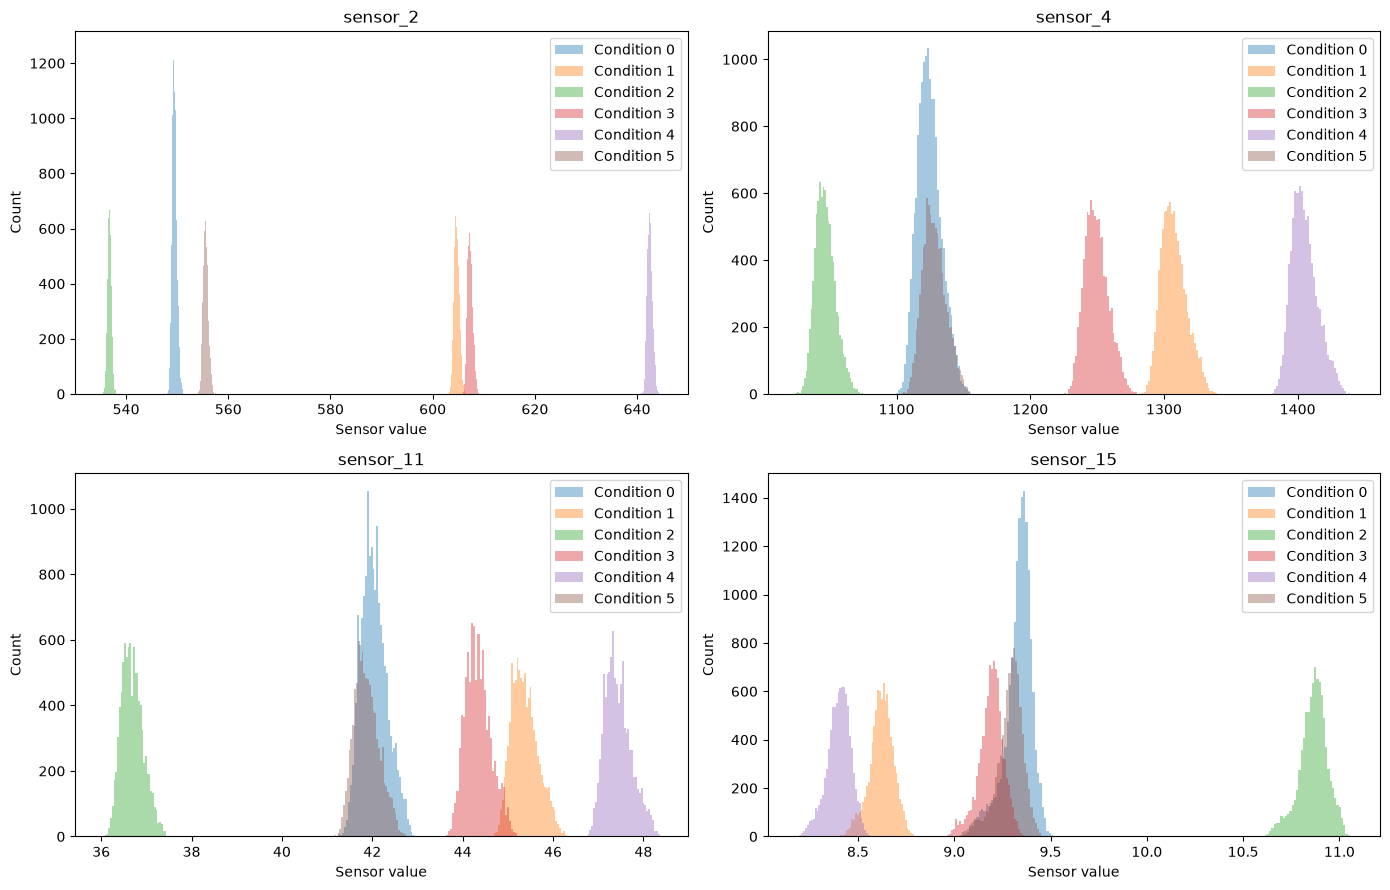

In [25]:
import matplotlib.pyplot as plt

sensors_to_plot = [
    "sensor_2",
    "sensor_4",
    "sensor_11",
    "sensor_15",
]

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(14, 9),
)

axes = axes.flatten()

for ax, sensor in zip(
    axes,
    sensors_to_plot,
):
    for condition in sorted(
        train_fd004["operating_condition"].unique()
    ):
        values = train_fd004.loc[
            train_fd004["operating_condition"] == condition,
            sensor,
        ]

        ax.hist(
            values,
            bins=40,
            alpha=0.4,
            label=f"Condition {condition}",
        )

    ax.set_title(sensor)
    ax.set_xlabel("Sensor value")
    ax.set_ylabel("Count")
    ax.legend()

plt.tight_layout()
plt.show()

In [21]:
train_fd004.operating_condition.value_counts()

operating_condition
0    15395
4     9238
1     9224
5     9162
2     9139
3     9091
Name: count, dtype: int64

In [ ]:
sensor_columns = [
    col
    for col in train_fd004.columns
    if col.startswith("sensor_")
]

condition_effects = []

for sensor in sensor_columns:
    grouped = train_fd004.groupby("operating_condition")[sensor]

    # Condition 0:
    # 642.1
    # 642.3
    # 642.0
    # ...

    # Condition 1:
    # 604.9
    # 605.2
    # 604.7
    # ...

    # Condition 2:
    # ...

    condition_means = grouped.mean()
    # condition 0    642
    # condition 1    605
    # condition 2    550
    # condition 3    620
    # condition 4    590
    # condition 5    670
    
    condition_stds = grouped.std()
    # condition 0    0.5
    # condition 1    0.4
    # condition 2    0.6
    # condition 3    0.5
    # condition 4    0.4
    # condition 5    0.5

    between_condition_std = condition_means.std()
    # standard deviation of [642, 605, 550, 620, 590, 670]

    average_within_condition_std = condition_stds.mean()
    # mean of standard deviations [0.5, 0.4, 0.6, 0.5, 0.4, 0.5]

    ratio = (
        between_condition_std
        / average_within_condition_std
        if average_within_condition_std > 0
        else float("inf")
    )

    condition_effects.append({
        "sensor": sensor,
        "between_condition_std": between_condition_std,
        "avg_within_condition_std": average_within_condition_std,
        "condition_effect_ratio": ratio,
    })

condition_effect_df = pd.DataFrame(
    condition_effects
).sort_values(
    "condition_effect_ratio",
    ascending=False,
)

condition_effect_df

,sensor,between_condition_std,avg_within_condition_std,condition_effect_ratio
0,sensor_1,28.528479,0.000000,inf
18,sensor_19,6.152302,0.000000,inf
17,sensor_18,168.118312,0.000000,inf
4,sensor_5,3.861282,0.000000,inf
7,sensor_8,167.973087,0.206728,812.532453
12,sensor_13,146.890646,0.216963,677.030832
5,sensor_6,5.850986,0.014807,395.137078
1,sensor_2,41.517804,0.479253,86.630305
11,sensor_12,150.788527,1.784017,84.521899
6,sensor_7,159.903155,1.902518,84.048152
